UID: 22BAI71060

=== Data Preparation ===
Initial shapes:
Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing data shape: (10000, 28, 28)
Testing labels shape: (10000,)

After preprocessing:
Training data shape: (60000, 784)
Training labels shape: (60000, 10)

=== Model Creation ===

=== Comparative Analysis of Optimizers ===

Training with: Adagrad, Epochs: 5, Batch Size: 32


C:\Users\WADEHRA\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7436 - loss: 0.8204 - val_accuracy: 0.9377 - val_loss: 0.2023
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9509 - loss: 0.1664 - val_accuracy: 0.9631 - val_loss: 0.1261
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9679 - loss: 0.1096 - val_accuracy: 0.9701 - val_loss: 0.1050
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9772 - loss: 0.0761 - val_accuracy: 0.9696 - val_loss: 0.1003
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9830 - loss: 0.0588 - val_accuracy: 0.9744 - val_loss: 0.0878
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 885us/step - accuracy: 0.9675 - loss: 0.0994

Training with: Adagrad, Epochs: 5, Batch Size: 64
Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6970 - loss: 1.0279 - val_accuracy: 0.9319 - val_loss: 0.2274
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9335 - loss: 0.2244 - val_accuracy:

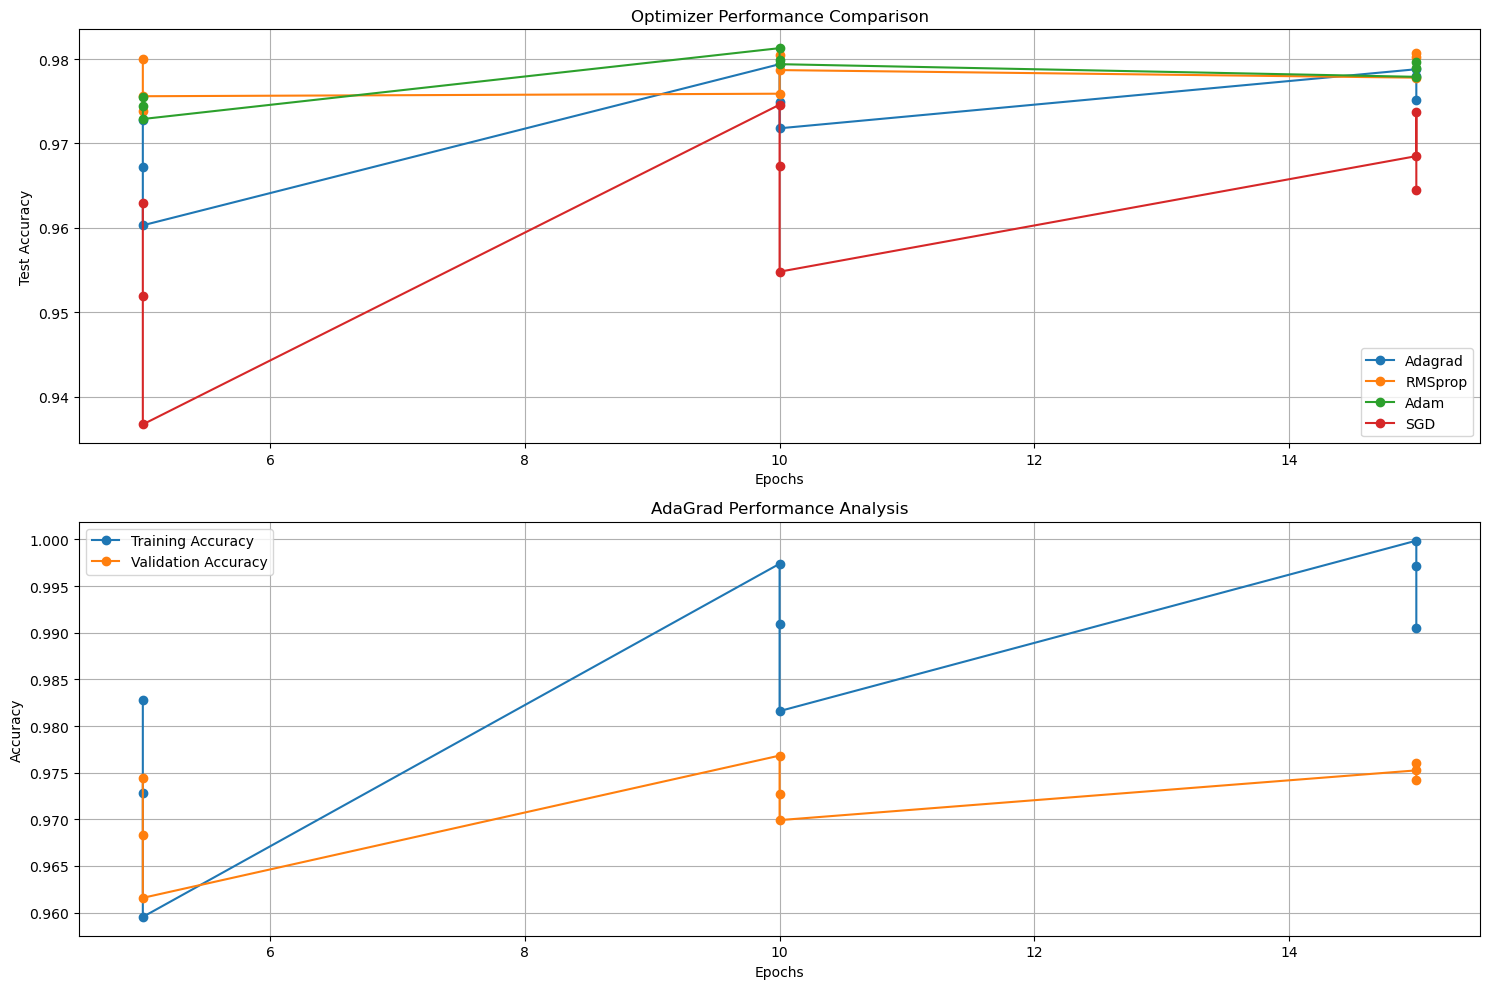


Results have been saved to 'optimizer_results.csv'
Visualization has been saved as 'optimizer_comparison.png'


In [1]:
# Import required libraries
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow.keras.optimizers import Adagrad, RMSprop, Adam, SGD

print("UID: 22BAI71060")

# 1. Data Preparation
print("\n=== Data Preparation ===")

# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Print initial data shapes
print("Initial shapes:")
print("Training data shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing data shape:", x_test.shape)
print("Testing labels shape:", y_test.shape)

# Normalize the images to range [0, 1]
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

# Flatten the images (reshape to 1D)
x_train = x_train.reshape((x_train.shape[0], 28 * 28))
x_test = x_test.reshape((x_test.shape[0], 28 * 28))

# One-hot encode the labels
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

print("\nAfter preprocessing:")
print("Training data shape:", x_train.shape)
print("Training labels shape:", y_train.shape)

# 2. Model Definition
print("\n=== Model Creation ===")

# Define optimizer classes and parameters (not instances)
optimizers = {
    'Adagrad': (Adagrad, {'learning_rate': 0.01}),
    'RMSprop': (RMSprop, {'learning_rate': 0.001}),
    'Adam': (Adam, {'learning_rate': 0.001}),
    'SGD': (SGD, {'learning_rate': 0.01})
}

epochs_list = [5, 10, 15]
batch_sizes = [32, 64, 128]

# Create empty lists to store results
results = []

print("\n=== Comparative Analysis of Optimizers ===")

for opt_name, (optimizer_class, optimizer_params) in optimizers.items():
    for epoch in epochs_list:
        for batch_size in batch_sizes:
            print(f"\nTraining with: {opt_name}, Epochs: {epoch}, Batch Size: {batch_size}")
            
            # Reset model
            model = Sequential([
                Dense(512, activation='relu', input_shape=(28 * 28,)),
                Dense(512, activation='relu'),
                Dense(256, activation='relu'),
                Dense(128, activation='relu'),
                Dense(64, activation='relu'),
                Dense(10, activation='softmax')
            ])
            
            # Create a fresh optimizer instance for each model
            optimizer = optimizer_class(**optimizer_params)
            
            # Compile model
            model.compile(optimizer=optimizer,
                        loss='categorical_crossentropy',
                        metrics=['accuracy'])
            
            # Train model
            history = model.fit(x_train, y_train,
                              epochs=epoch,
                              batch_size=batch_size,
                              validation_split=0.2,
                              verbose=1)
            
            # Evaluate model
            test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=1)
            
            # Store results
            results.append({
                'Optimizer': opt_name,
                'Epochs': epoch,
                'Batch Size': batch_size,
                'Test Accuracy': test_accuracy,
                'Test Loss': test_loss,
                'Final Training Accuracy': history.history['accuracy'][-1],
                'Final Validation Accuracy': history.history['val_accuracy'][-1]
            })

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Display results table
print("\n=== Results Table ===")
print(results_df.to_string(index=False))

# Create visualization
plt.figure(figsize=(15, 10))

# Plot test accuracy comparison
plt.subplot(2, 1, 1)
for opt in optimizers.keys():
    opt_results = results_df[results_df['Optimizer'] == opt]
    plt.plot(opt_results['Epochs'], opt_results['Test Accuracy'], 'o-', label=opt)

plt.title('Optimizer Performance Comparison')
plt.xlabel('Epochs')
plt.ylabel('Test Accuracy')
plt.legend()
plt.grid(True)

# Plot training vs validation accuracy for AdaGrad
plt.subplot(2, 1, 2)
adagrad_results = results_df[results_df['Optimizer'] == 'Adagrad']
plt.plot(adagrad_results['Epochs'], adagrad_results['Final Training Accuracy'], 'o-', label='Training Accuracy')
plt.plot(adagrad_results['Epochs'], adagrad_results['Final Validation Accuracy'], 'o-', label='Validation Accuracy')
plt.title('AdaGrad Performance Analysis')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('optimizer_comparison.png')
plt.show()

# Save results to CSV
results_df.to_csv('optimizer_results.csv', index=False)
print("\nResults have been saved to 'optimizer_results.csv'")
print("Visualization has been saved as 'optimizer_comparison.png'")